In [6]:
# read in data
import pandas as pd

# training dataset 
df = pd.read_csv('../../SAC105_Data/data.csv')

# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


If you need to use this method, please apply the `update_vs` function to update the virtual data before performing the following calculation.


In [7]:
from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)

# EI + HV

Please ensure that \( T = 0 \) is set in EI here. 



In [8]:
# use isosurface method

from BgoKit import ToolKit
import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 


Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.EI(T=0)  

Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.EI(T=0)


 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 20:50:35  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current optimal is : 0
The next datum recomended by Expected Improvement : 
 x =  [86.9  5.5  5.5  0.6]
The predictions of Bgolearn are : 
 y =  105.98419757493524
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current o

Please refer to the tutorial at https://github.com/Bgolearn/CodeDemo/tree/main/multiobject_examples_book/MO_selection/EI_HV
Note: This function is developed for expected improvement and probability improvement. It has not been tested on other UFs yet.
As this is an educational attempt in the book, it is not recommended for use in real research without rigorous validation.


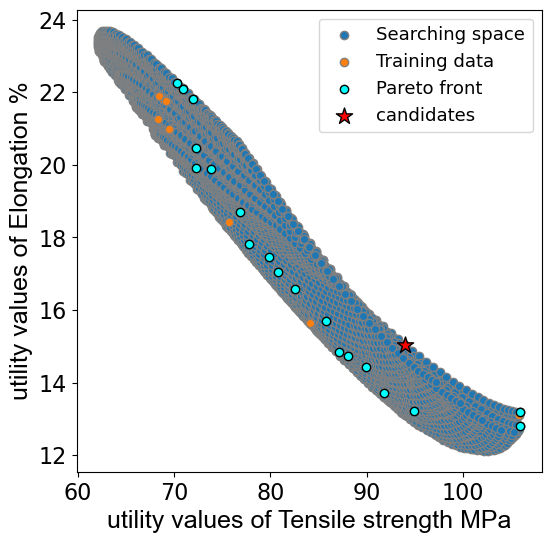

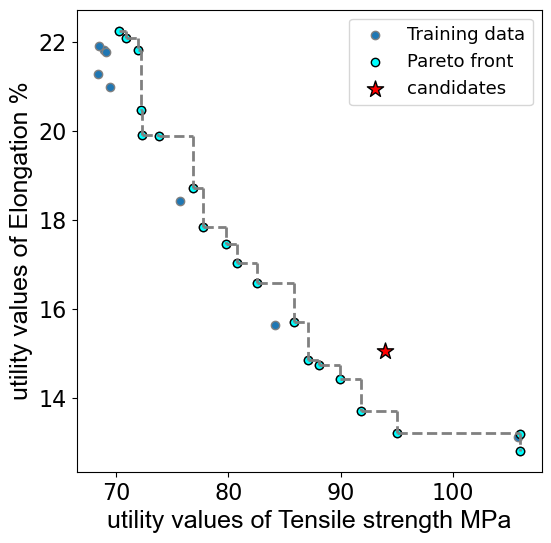

The next recommended data by method EV is: [88.8  3.5  5.5  0.7]
The hypervolume improvement is: 8.160348076094124


In [9]:
names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])

### 1st

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:01:10  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current optimal is : 0
The next datum recomended by Expected Improvement : 
 x =  [86.9  5.5  5.5  0.6]
The predictions of Bgolearn are : 
 y =  105.98419757493524
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current o

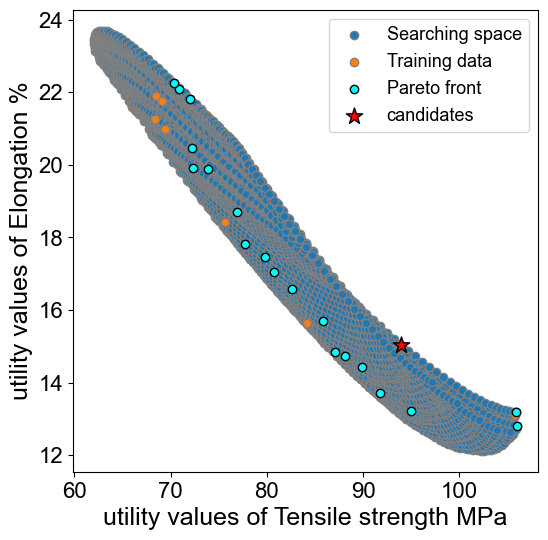

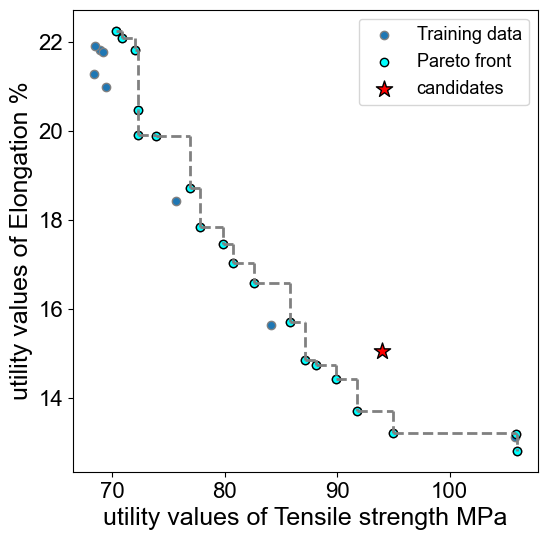

The next recommended data by method EV is: [88.8  3.5  5.5  0.7]
The hypervolume improvement is: 8.160348076094124
the recommended data is : [88.8  3.5  5.5  0.7]
Predicted value for target 1: 88.1156952632948
Predicted value for target 2: 15.490645337998899


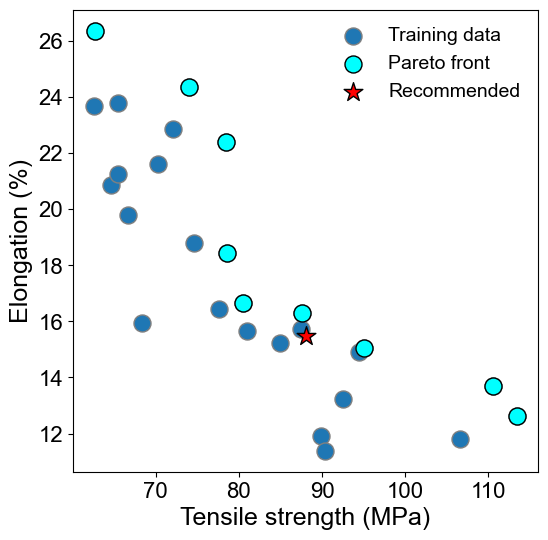

In [11]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = '../../SAC105_Data/data.csv'

# EI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.EI(T=0)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.EI(T=0)  


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_EI_1.png', dpi=800)
plt.savefig('ParetoF_EI_1.svg', dpi=800)
plt.show()
#################################################

In [12]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./EI_iter/first.csv', index=False)

### 2nd

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:04:15  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current optimal is : 0
The next datum recomended by Expected Improvement : 
 x =  [86.9  5.5  5.5  0.6]
The predictions of Bgolearn are : 
 y =  105.38868828385202
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current o

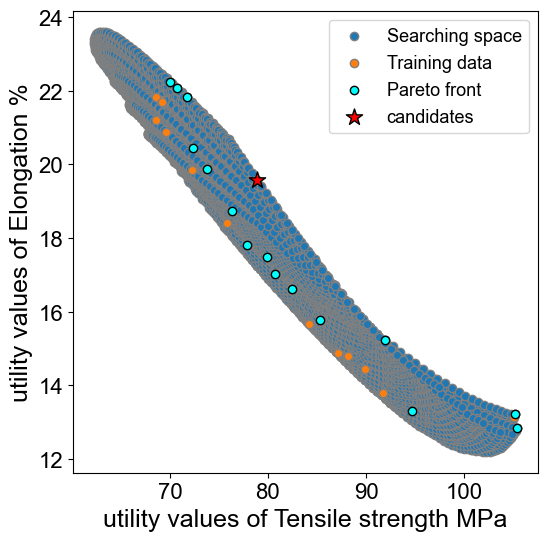

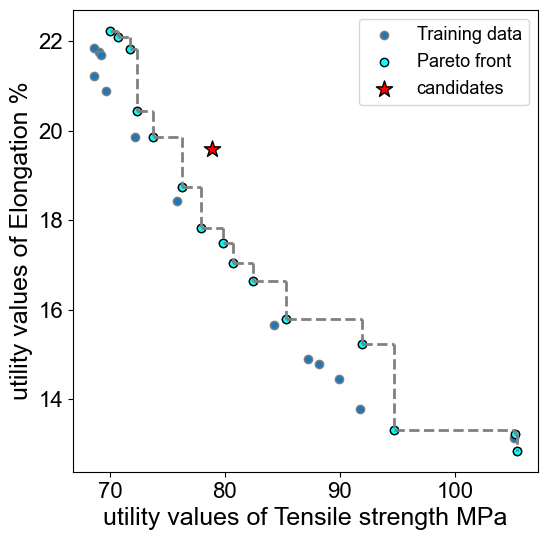

The next recommended data by method EV is: [90.6  2.3  5.5  0.1]
The hypervolume improvement is: 6.973364677559857
the recommended data is : [90.6  2.3  5.5  0.1]
Predicted value for target 1: 82.58835359216664
Predicted value for target 2: 17.927534861802673


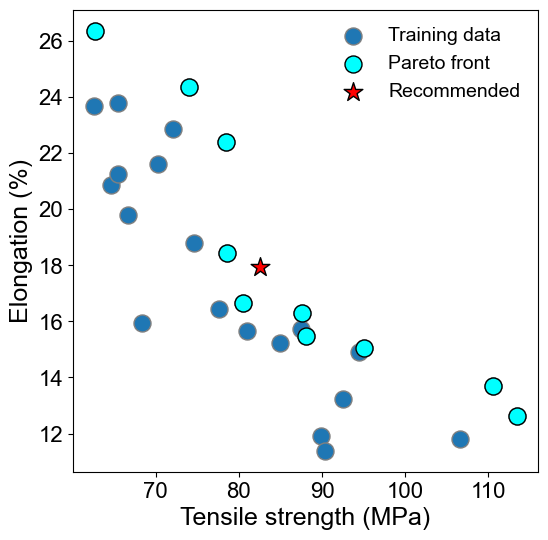

In [13]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = './EI_iter/first.csv'

# EI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.EI(T=0)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.EI(T=0)  


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_EI_2.png', dpi=800)
plt.savefig('ParetoF_EI_2.svg', dpi=800)
plt.show()
#################################################

In [14]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./EI_iter/second.csv', index=False)

### 3rd

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:05:09  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current optimal is : 0
The next datum recomended by Expected Improvement : 
 x =  [86.9  5.5  5.5  0.6]
The predictions of Bgolearn are : 
 y =  105.78582774170496
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
current o

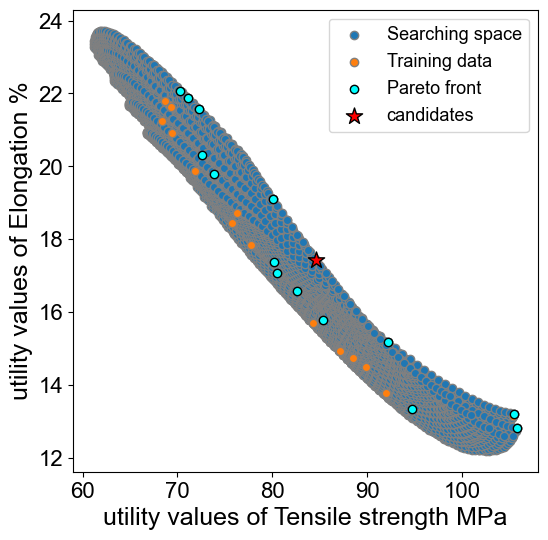

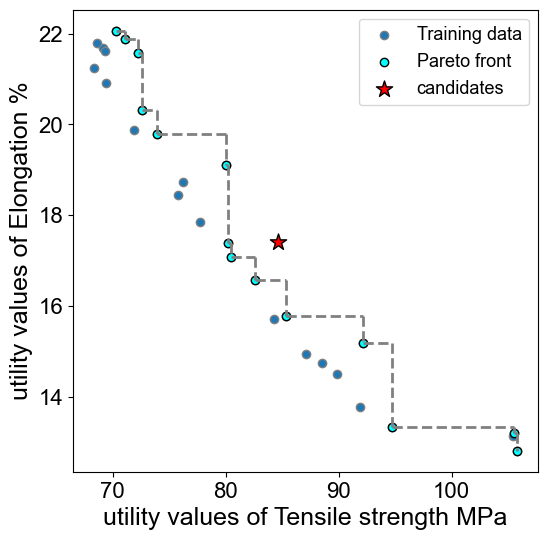

The next recommended data by method EV is: [89.8  3.   5.5  0.2]
The hypervolume improvement is: 5.148983564897321
the recommended data is : [89.8  3.   5.5  0.2]
Predicted value for target 1: 84.0571652062428
Predicted value for target 2: 16.737876160510357


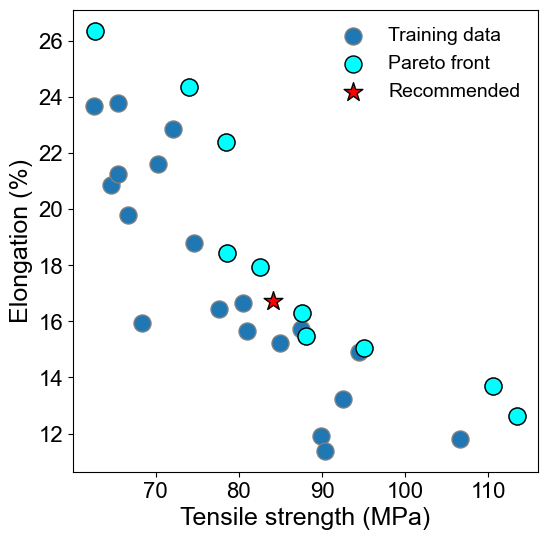

In [15]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = './EI_iter/second.csv'

# EI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.EI(T=0)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.EI(T=0)  


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_EI_3.png', dpi=800)
plt.savefig('ParetoF_EI_3.svg', dpi=800)
plt.show()
#################################################

# PoI + HV

In [3]:
# use isosurface method

from BgoKit import ToolKit
import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 


Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.PoI(T=72)  

Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.PoI(T=20)



 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 13:45:56  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
The current optimal is : 72
The next datum recomended by Probability of Improvement  : 
 x =  [87.6  5.4  4.9  0.6]
The predictions of Bgolearn are : 
 y =  104.38469843109026
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the use

In [4]:
score_2

array([0.82714561, 0.85411517, 0.85268576, ..., 0.90838033, 0.86360933,
       0.92550646])

Please refer to the tutorial at https://github.com/Bgolearn/CodeDemo/tree/main/multiobject_examples_book/MO_selection/EI_HV
Note: This function is developed for expected improvement and probability improvement. It has not been tested on other UFs yet.
As this is an educational attempt in the book, it is not recommended for use in real research without rigorous validation.


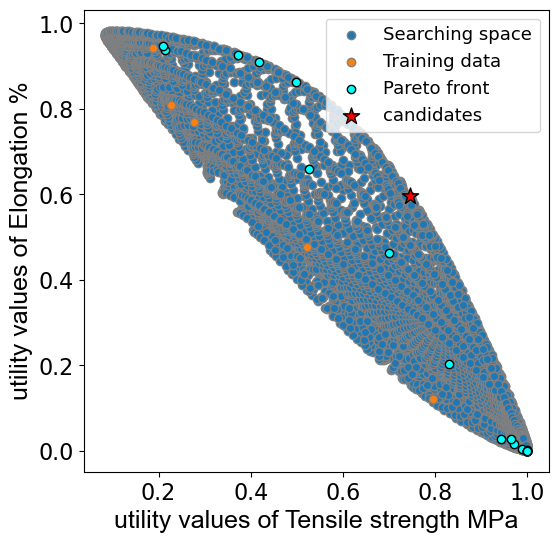

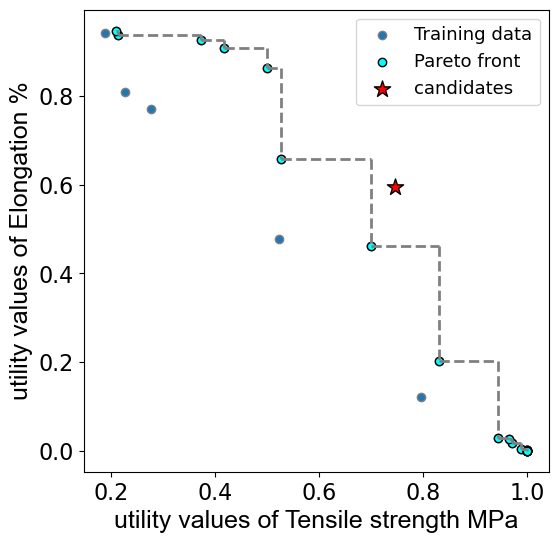

The next recommended data by method EV is: [91.2  2.   5.1  0.2]
The hypervolume improvement is: 0.0410260937495619


In [5]:

names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])

### first

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:24:49  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
The current optimal is : 72
The next datum recomended by Probability of Improvement  : 
 x =  [87.6  5.4  4.9  0.6]
The predictions of Bgolearn are : 
 y =  104.38469843109026
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the use

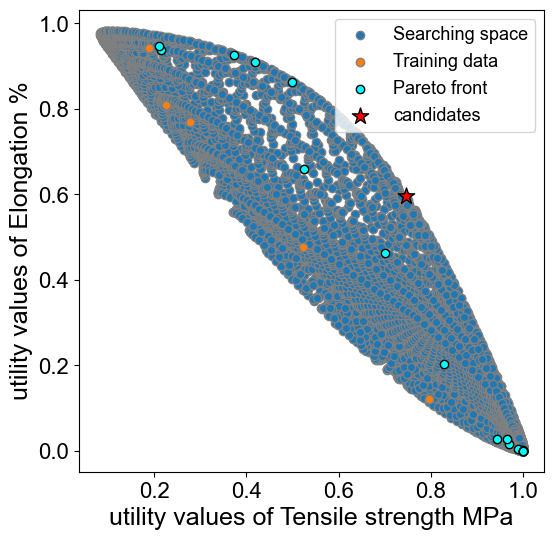

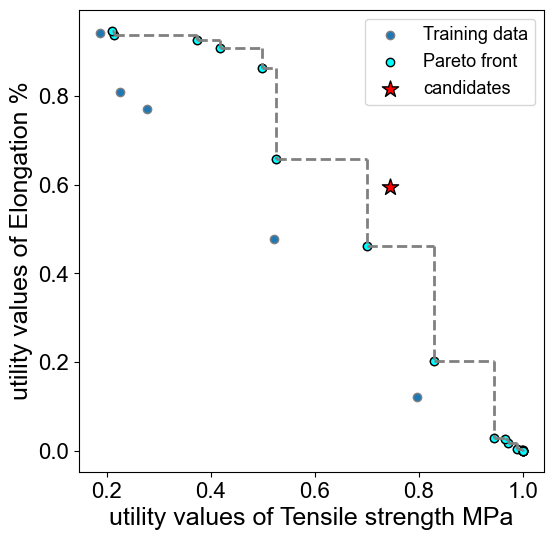

The next recommended data by method EV is: [91.2  2.   5.1  0.2]
The hypervolume improvement is: 0.0410260937495619
the recommended data is : [91.2  2.   5.1  0.2]
Predicted value for target 1: 79.5503241925359
Predicted value for target 2: 19.28528376057898


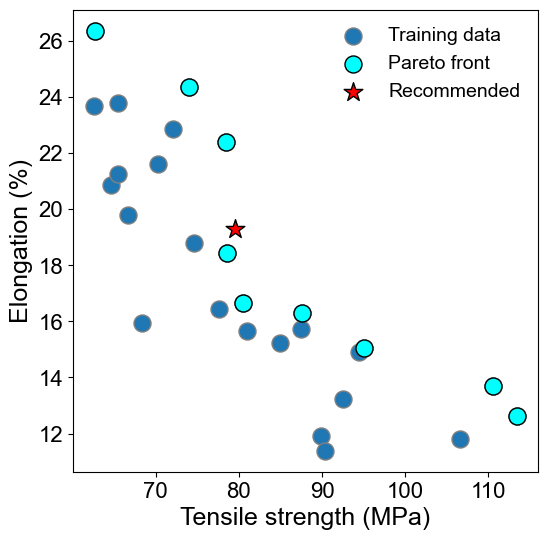

In [16]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = '../../SAC105_Data/data.csv'

# PoI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.PoI(T=72)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.PoI(T=20) 


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_PI_1.png', dpi=800)
plt.savefig('ParetoF_PI_1.svg', dpi=800)
plt.show()
#################################################

In [17]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./PoI_iter/first.csv', index=False)

### second

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:32:41  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
The current optimal is : 72
The next datum recomended by Probability of Improvement  : 
 x =  [87.6  5.4  4.9  0.6]
The predictions of Bgolearn are : 
 y =  104.57427653228278
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the use

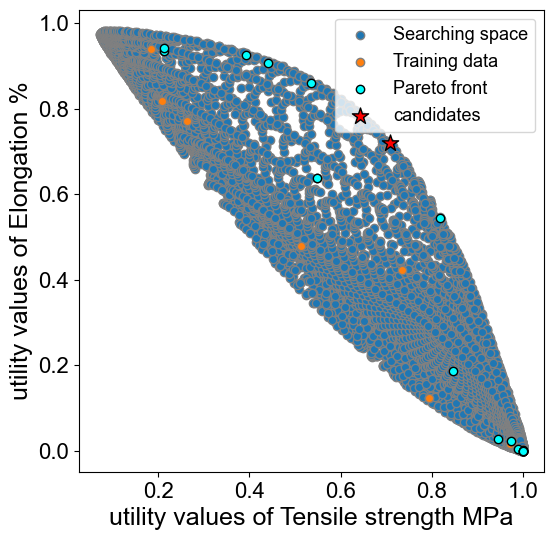

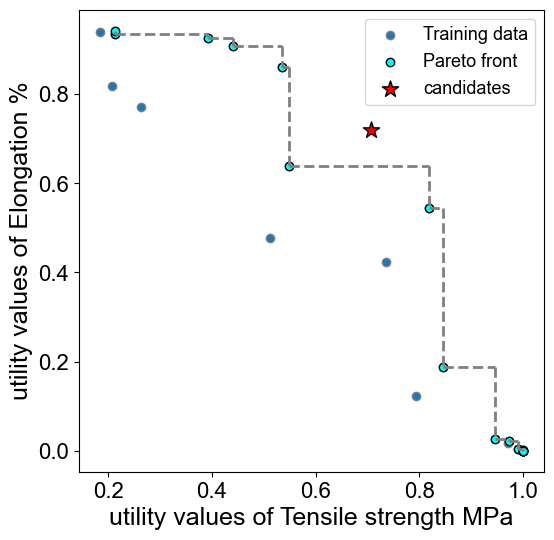

The next recommended data by method EV is: [91.6  1.9  4.8  0.2]
The hypervolume improvement is: 0.028940332046288764
the recommended data is : [91.6  1.9  4.8  0.2]
Predicted value for target 1: 76.83534846906014
Predicted value for target 2: 20.572458831543848


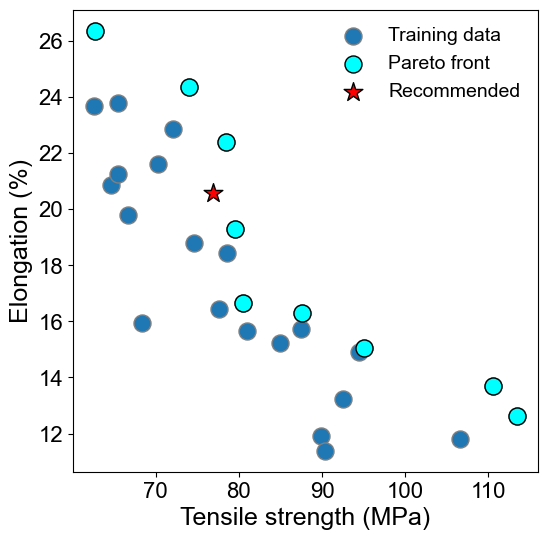

In [18]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = './PoI_iter/first.csv'

# PoI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.PoI(T=72)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.PoI(T=20) 


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_PI_2.png', dpi=800)
plt.savefig('ParetoF_PI_2.svg', dpi=800)
plt.show()
#################################################

In [19]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./PoI_iter/second.csv', index=False)

### third 

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-16 21:33:43  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the user.
The current optimal is : 72
The next datum recomended by Probability of Improvement  : 
 x =  [87.6  5.4  4.9  0.6]
The predictions of Bgolearn are : 
 y =  104.71203913521585
The internal model is instantiated with optimized homogenous noise
The baseline is assigned by the use

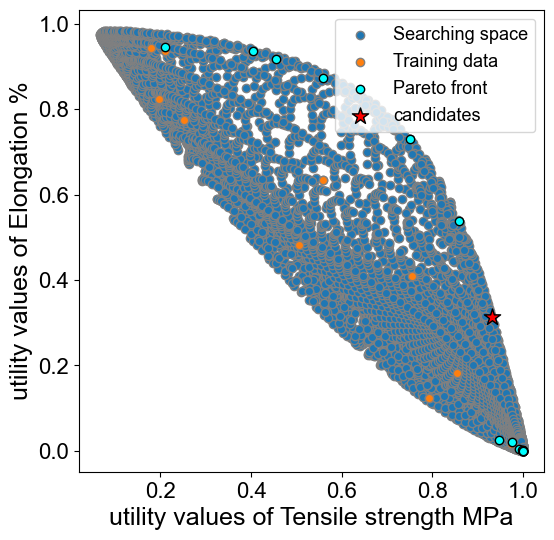

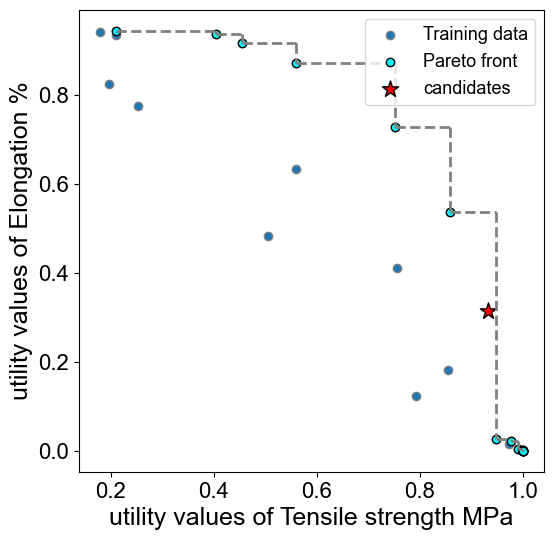

The next recommended data by method EV is: [90.6  2.3  5.4  0.2]
The hypervolume improvement is: 0.020710733277893967
the recommended data is : [90.6  2.3  5.4  0.2]
Predicted value for target 1: 81.8174878344935
Predicted value for target 2: 17.918813150528603


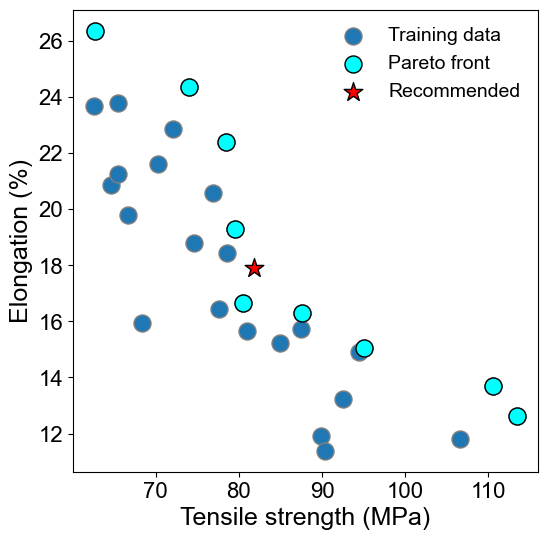

In [20]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = './PoI_iter/second.csv'

# PoI+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS


df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')


from BgoKit import ToolKit 
vs = ToolKit.update_vs(df, vs)


Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.PoI(T=72)  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.PoI(T=20) 


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch_user(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_PI_3.png', dpi=800)
plt.savefig('ParetoF_PI_3.svg', dpi=800)
plt.show()
#################################################